0:	learn: 3.6815530	total: 165ms	remaining: 1m 22s
100:	learn: 0.9528604	total: 2.87s	remaining: 11.3s
200:	learn: 0.7017899	total: 5.67s	remaining: 8.43s
300:	learn: 0.5680280	total: 8.33s	remaining: 5.51s
400:	learn: 0.4511158	total: 11s	remaining: 2.7s
499:	learn: 0.3662158	total: 13.5s	remaining: 0us


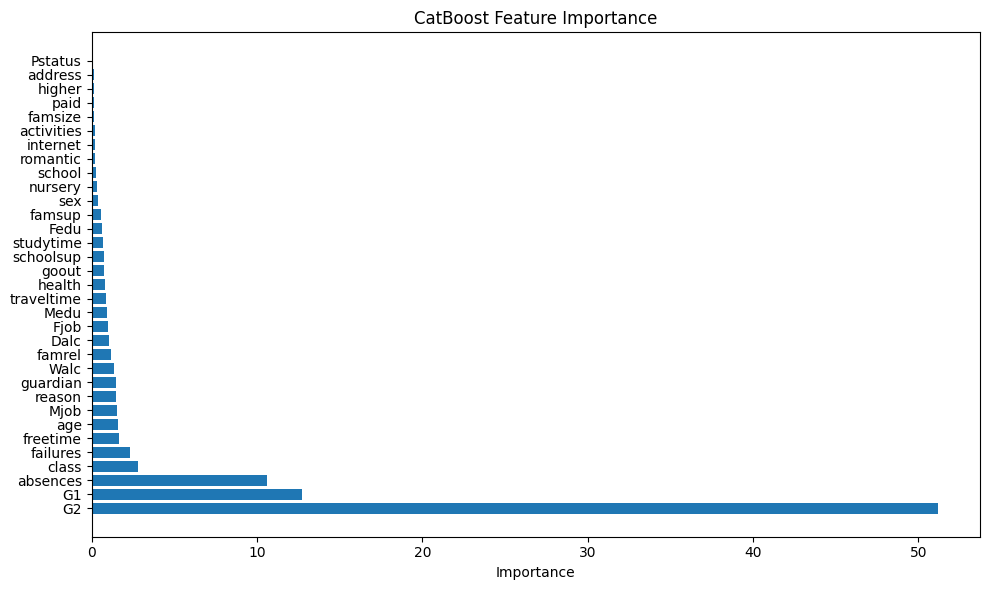

训练完成并保存模型和训练集数据。


In [2]:
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# 读取清洗后的完整数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 明确指定哪些列是类别特征
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
                    'nursery', 'higher', 'internet', 'romantic', 'class']

# 把这些列转换为 category 类型（否则 CatBoost 会报错）
df[categorical_cols] = df[categorical_cols].astype("category")

# 特征和目标
X = df.drop(columns=["G3"])
y = df["G3"]
cat_features = categorical_cols  # 显式告诉 CatBoost 哪些是 categorical

# 划分训练集
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

# 保存训练集数据
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/catboost_train_data_full.csv", index=False)

# 创建 Pool 对象
train_pool = Pool(X_train, y_train, cat_features=cat_features)

# 初始化 CatBoost 模型
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

# 训练模型
model.fit(train_pool)

# 保存模型
model.save_model("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/catboost_model_full.cbm")

# 特征重要性可视化与保存
importances = model.get_feature_importance(prettified=True)
importances.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/catboost_feature_importance_full.csv", index=False)

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature Id'], importances['Importances'])
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.savefig("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/catboost_feature_importance_full.png")
plt.show()

print("训练完成并保存模型和训练集数据。")


评估结果：
MSE: 2.0484
R² : 0.8634


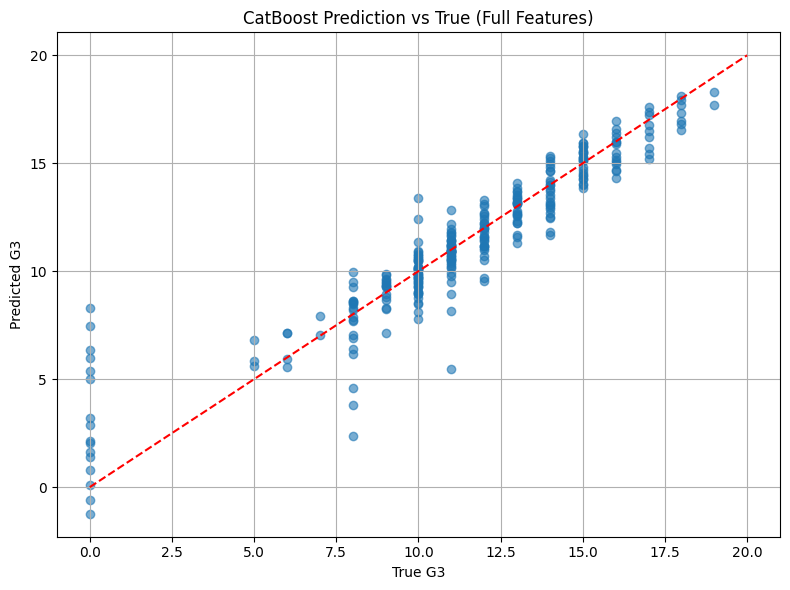

In [4]:
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 读取清洗后的完整数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=["G3"])
y = df["G3"]
cat_features = X.select_dtypes(include="category").columns.tolist()

# 划分评估集
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 保存评估集数据
eval_df = pd.concat([X_eval, y_eval], axis=1)
eval_df.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/catboost_eval_data_full.csv", index=False)

# 加载模型
model = CatBoostRegressor()
model.load_model("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/catboost_model_full.cbm")

# 预测
y_pred = model.predict(X_eval)

# 评估
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

print(f"\n评估结果：\nMSE: {mse:.4f}\nR² : {r2:.4f}")

# 可视化真实 vs 预测
plt.figure(figsize=(8, 6))
plt.scatter(y_eval, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], 'r--')
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("CatBoost Prediction vs True (Full Features)")
plt.grid(True)
plt.tight_layout()
plt.show()